<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_4_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip -q initial_data.zip

replace __MACOSX/._initial_data_1? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [34]:
import os
print(os.listdir())

['.config', 'Week_3_outputs.txt', '.ipynb_checkpoints', 'Week_3_inputs.txt', 'Week_2_outputs.txt', 'week_1_outputs.txt', 'initial_data_1', 'week_1_inputs.txt', 'Week_2_inputs.txt', 'week_4_data.zip', 'week_4_data', 'drive', '__MACOSX', 'sample_data']


In [21]:
def load_clean_txt(file):
    with open(file, "r") as f:
        text = f.read().strip()

    # Remove wrappers
    text = text.replace("array(", "")
    text = text.replace(")", "")

    # Force close if missing
    if not text.endswith("]"):
        text += "]"

    return np.array(eval(text))

In [33]:
import numpy as np
import os
import re

os.makedirs("week_4_data", exist_ok=True)

def load_inputs(file):
    with open(file, "r") as f:
        text = f.read()

    rows = re.findall(r"\[([0-9eE\.\-\+,\s]+)\]", text)
    return [np.array([float(x) for x in row.replace(",", " ").split()]) for row in rows]

def load_outputs(file):
    with open(file, "r") as f:
        text = f.read()

    nums = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)?", text)
    return [float(x) for x in nums]

week1_inputs = load_inputs("week_1_inputs.txt")
week1_outputs = load_outputs("week_1_outputs.txt")

week2_inputs = load_inputs("Week_2_inputs.txt")
week2_outputs = load_outputs("Week_2_outputs.txt")

week3_inputs = load_inputs("Week_3_inputs.txt")
week3_outputs = load_outputs("Week_3_outputs.txt")

for fn in range(1, 9):

    X_initial = np.load(f"initial_data_1/function_{fn}/initial_inputs.npy")
    y_initial = np.load(f"initial_data_1/function_{fn}/initial_outputs.npy")

    X_w1 = week1_inputs[fn-1].reshape(1, -1)
    y_w1 = np.array([week1_outputs[fn-1]])

    X_w2 = week2_inputs[fn-1].reshape(1, -1)
    y_w2 = np.array([week2_outputs[fn-1]])

    X_w3 = week3_inputs[fn-1].reshape(1, -1)
    y_w3 = np.array([week3_outputs[fn-1]])

    X_all = np.vstack([X_initial, X_w1, X_w2, X_w3])
    y_all = np.concatenate([y_initial, y_w1, y_w2, y_w3])

    np.save(f"week_4_data/function_{fn}_inputs.npy", X_all)
    np.save(f"week_4_data/function_{fn}_outputs.npy", y_all)

print("Week 4 dataset created successfully")

Week 4 dataset created successfully


In [27]:
import os
print(os.listdir("week_4_data"))

['function_8_inputs.npy', 'function_6_inputs.npy', 'function_5_outputs.npy', 'function_6_outputs.npy', 'function_5_inputs.npy', 'function_3_outputs.npy', 'function_7_outputs.npy', 'function_4_outputs.npy', 'function_8_outputs.npy', 'function_7_inputs.npy', 'function_3_inputs.npy', 'function_1_outputs.npy', 'function_2_outputs.npy', 'function_1_inputs.npy', 'function_2_inputs.npy', 'function_4_inputs.npy']


In [32]:
!zip -r week_4_data.zip week_4_data

updating: week_4_data/ (stored 0%)
updating: week_4_data/function_8_inputs.npy (deflated 10%)
updating: week_4_data/function_6_inputs.npy (deflated 11%)
updating: week_4_data/function_5_outputs.npy (deflated 22%)
updating: week_4_data/function_6_outputs.npy (deflated 20%)
updating: week_4_data/function_5_inputs.npy (deflated 13%)
updating: week_4_data/function_3_outputs.npy (deflated 25%)
updating: week_4_data/function_7_outputs.npy (deflated 16%)
updating: week_4_data/function_4_outputs.npy (deflated 15%)
updating: week_4_data/function_8_outputs.npy (deflated 13%)
updating: week_4_data/function_7_inputs.npy (deflated 10%)
updating: week_4_data/function_3_inputs.npy (deflated 15%)
updating: week_4_data/function_1_outputs.npy (deflated 31%)
updating: week_4_data/function_2_outputs.npy (deflated 29%)
updating: week_4_data/function_1_inputs.npy (deflated 23%)
updating: week_4_data/function_2_inputs.npy (deflated 23%)
updating: week_4_data/function_4_inputs.npy (deflated 11%)


In [30]:
from google.colab import files
files.download("week_4_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Function 1
Input shape: (13, 2)
Output shape: (13,)
Best output: 64.0
Worst output: -0.0036060626443634764
Mean output: 14.768953379796587


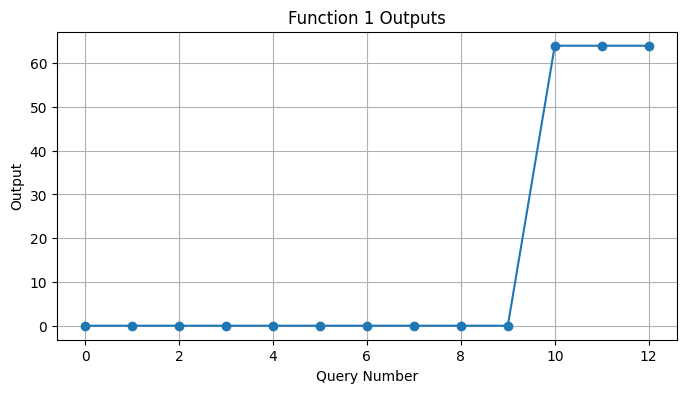


Function 2
Input shape: (13, 2)
Output shape: (13,)
Best output: 0.6112052157614438
Worst output: -0.06562362443733738
Mean output: 0.17744135870764796


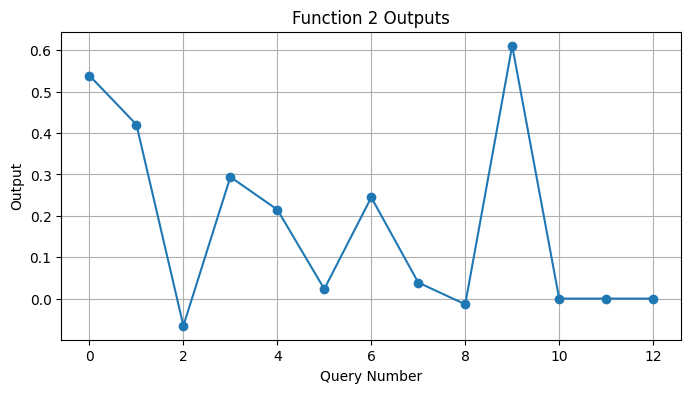


Function 3
Input shape: (18, 3)
Output shape: (18,)
Best output: 64.0
Worst output: -0.3989255131463011
Mean output: 10.577360854393232


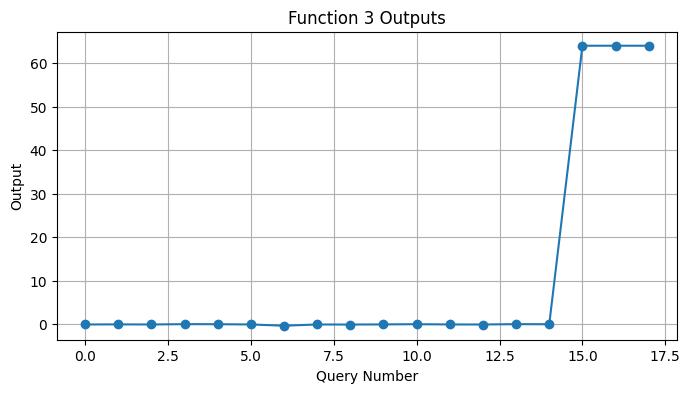


Function 4
Input shape: (33, 4)
Output shape: (33,)
Best output: -0.03182956281754251
Worst output: -32.625660215962455
Mean output: -15.674336643244022


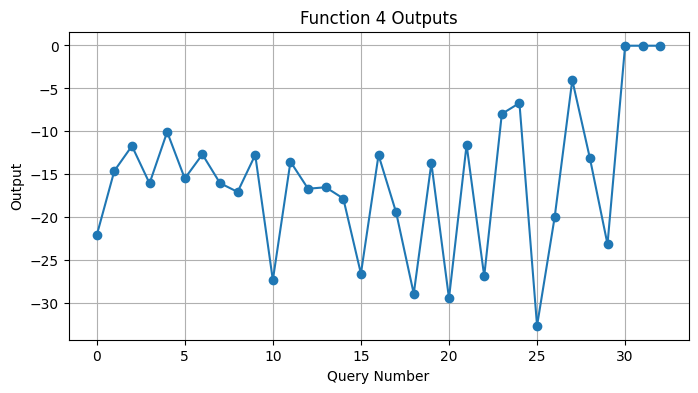


Function 5
Input shape: (23, 4)
Output shape: (23,)
Best output: 1088.8596181962705
Worst output: 0.1129397953712203
Mean output: 139.88858754696767


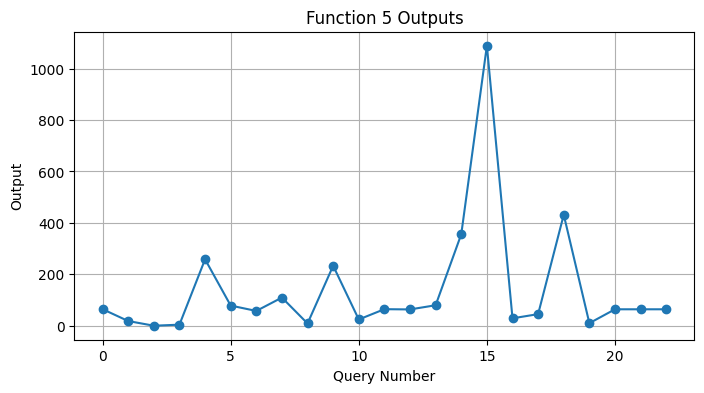


Function 6
Input shape: (23, 5)
Output shape: (23,)
Best output: -0.04090761844901528
Worst output: -2.5711696316081234
Mean output: -1.305674854314173


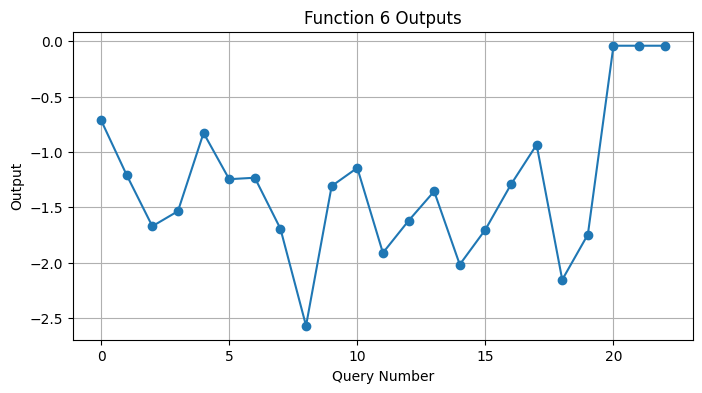


Function 7
Input shape: (33, 6)
Output shape: (33,)
Best output: 64.0
Worst output: 0.0027014650245082332
Mean output: 6.017824160021296


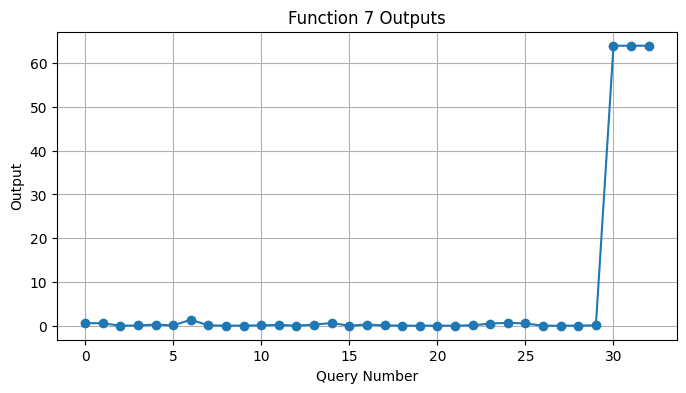


Function 8
Input shape: (43, 8)
Output shape: (43,)
Best output: 9.598482002566342
Worst output: -8.727516493155957
Mean output: 6.661126252258027


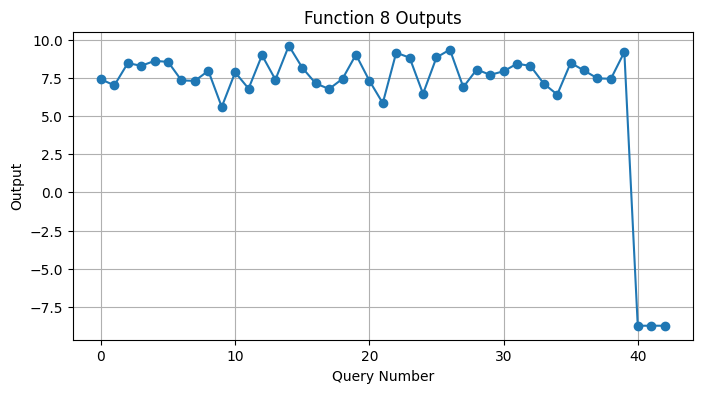

In [31]:
import numpy as np
import matplotlib.pyplot as plt

for fn in range(1, 9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    print(f"\nFunction {fn}")
    print("Input shape:", X.shape)
    print("Output shape:", y.shape)
    print("Best output:", np.max(y))
    print("Worst output:", np.min(y))
    print("Mean output:", np.mean(y))

    plt.figure(figsize=(8,4))
    plt.plot(y, marker='o')
    plt.title(f"Function {fn} Outputs")
    plt.xlabel("Query Number")
    plt.ylabel("Output")
    plt.grid(True)
    plt.show()

In [37]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# create folder for scaled data
os.makedirs("week_4_scaled", exist_ok=True)

scalers = {}

for fn in range(1, 9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    # Scale inputs only
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scalers[fn] = scaler

    # Save scaled inputs and original outputs
    np.save(f"week_4_scaled/function_{fn}_inputs_scaled.npy", X_scaled)
    np.save(f"week_4_scaled/function_{fn}_outputs.npy", y)

print("Week 4 scaling completed successfully")

Week 4 scaling completed successfully


In [38]:
import numpy as np

for fn in range(1, 9):
    X_scaled = np.load(f"week_4_scaled/function_{fn}_inputs_scaled.npy")
    y = np.load(f"week_4_scaled/function_{fn}_outputs.npy")

    print(f"\n===== Function {fn} =====")
    print("Scaled Input Shape:", X_scaled.shape)
    print("Output Shape:", y.shape)

    print("\nFirst 5 scaled inputs:")
    print(X_scaled[:5])

    print("\nBest Output:", np.max(y))
    print("Worst Output:", np.min(y))
    print("Mean Output:", np.mean(y))
    print("Std Dev of Inputs:", np.std(X_scaled, axis=0))


===== Function 1 =====
Scaled Input Shape: (13, 2)
Output Shape: (13,)

First 5 scaled inputs:
[[-0.8305573   0.42690057]
 [ 0.28855209  0.81524404]
 [ 0.97643271  0.32740765]
 [ 1.45638499 -1.22767099]
 [ 0.62124376  0.1564685 ]]

Best Output: 64.0
Worst Output: -0.0036060626443634764
Mean Output: 14.768953379796587
Std Dev of Inputs: [1. 1.]

===== Function 2 =====
Scaled Input Shape: (13, 2)
Output Shape: (13,)

First 5 scaled inputs:
[[ 0.78972252 -1.42575685]
 [ 1.80357571  0.55697232]
 [-1.71201621 -0.74420222]
 [ 1.64806939  0.35251674]
 [-0.22011828 -0.92152936]]

Best Output: 0.6112052157614438
Worst Output: -0.06562362443733738
Mean Output: 0.17744135870764796
Std Dev of Inputs: [1. 1.]

===== Function 3 =====
Scaled Input Shape: (18, 3)
Output Shape: (18,)

First 5 scaled inputs:
[[-1.00200543 -0.93316966 -0.56554878]
 [-0.71141991  0.47725293 -0.47148975]
 [ 0.49387545 -0.67668233 -0.86464237]
 [ 0.31964453  0.32462617 -0.20258358]
 [-1.15392139 -1.51583688  0.26593243]]




Function 1
Mean of scaled inputs: [ 1.70803542e-16 -2.39124959e-16]
Std of scaled inputs: [1. 1.]
Best output: 64.0
Mean output: 14.768953379796587


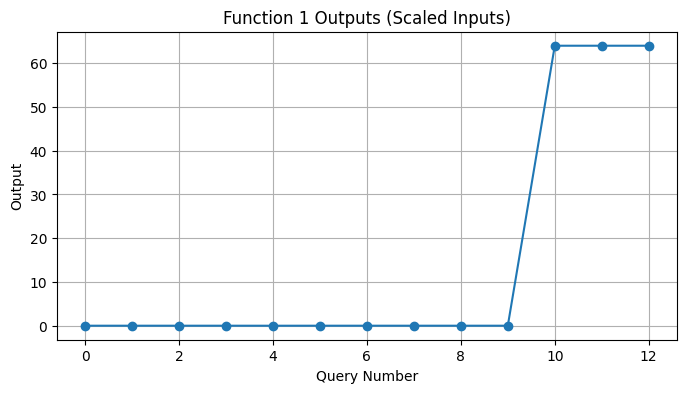


Function 2
Mean of scaled inputs: [2.73285668e-16 3.41607085e-17]
Std of scaled inputs: [1. 1.]
Best output: 0.6112052157614438
Mean output: 0.17744135870764796


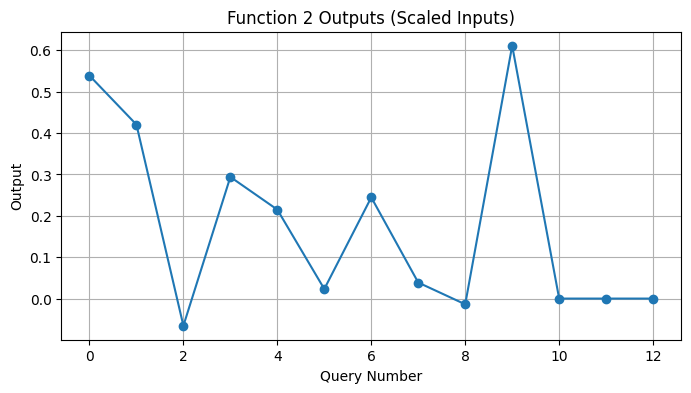


Function 3
Mean of scaled inputs: [1.80411242e-16 2.09708794e-16 6.47630098e-17]
Std of scaled inputs: [1. 1. 1.]
Best output: 64.0
Mean output: 10.577360854393232


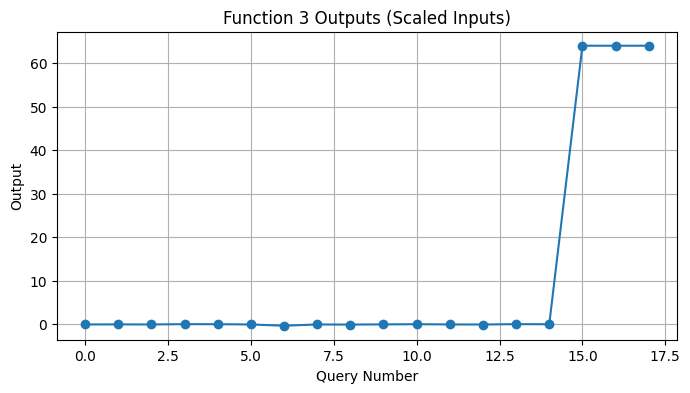


Function 4
Mean of scaled inputs: [ 3.58299249e-16 -3.01947020e-16 -1.54758361e-16  6.05576195e-16]
Std of scaled inputs: [1. 1. 1. 1.]
Best output: -0.03182956281754251
Mean output: -15.674336643244022


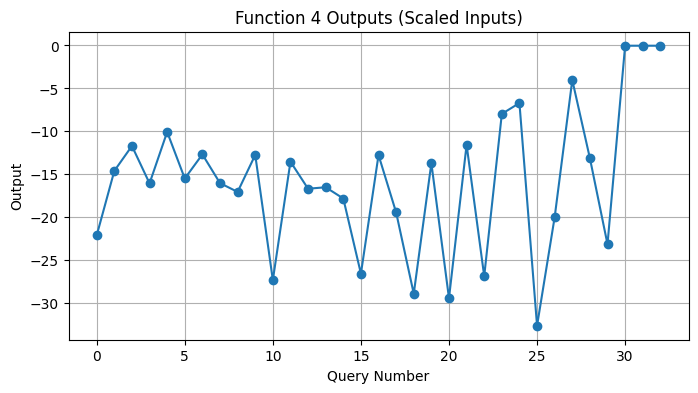


Function 5
Mean of scaled inputs: [-7.81983174e-16  1.73774039e-16 -1.93082265e-17 -1.54465812e-16]
Std of scaled inputs: [1. 1. 1. 1.]
Best output: 1088.8596181962705
Mean output: 139.88858754696767


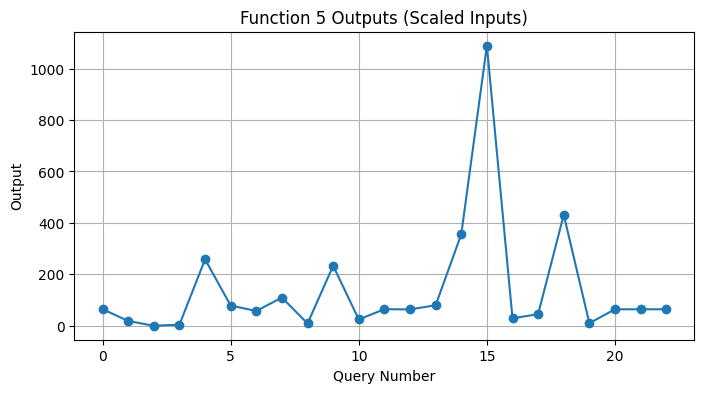


Function 6
Mean of scaled inputs: [-6.85442041e-16  1.93082265e-17 -6.75787928e-17  9.65411326e-17
  3.37893964e-17]
Std of scaled inputs: [1. 1. 1. 1. 1.]
Best output: -0.04090761844901528
Mean output: -1.305674854314173


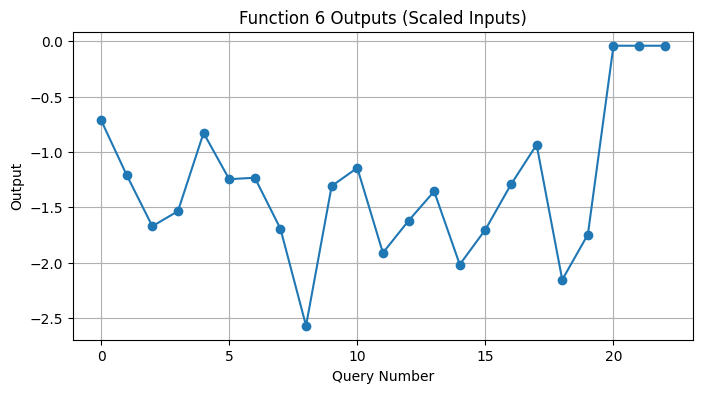


Function 7
Mean of scaled inputs: [ 1.48029737e-16 -6.72862439e-17 -6.22397756e-17  2.28773229e-16
  4.09605010e-16 -2.89330849e-16]
Std of scaled inputs: [1. 1. 1. 1. 1. 1.]
Best output: 64.0
Mean output: 6.017824160021296


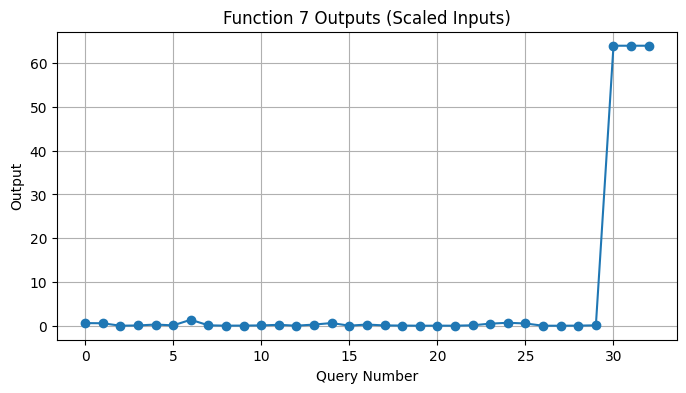


Function 8
Mean of scaled inputs: [ 1.04825709e-15 -1.70406325e-16 -4.02778586e-16 -5.88676394e-16
 -6.50642331e-16  2.89174369e-16 -7.33263579e-16 -2.22044605e-16]
Std of scaled inputs: [1. 1. 1. 1. 1. 1. 1. 1.]
Best output: 9.598482002566342
Mean output: 6.661126252258027


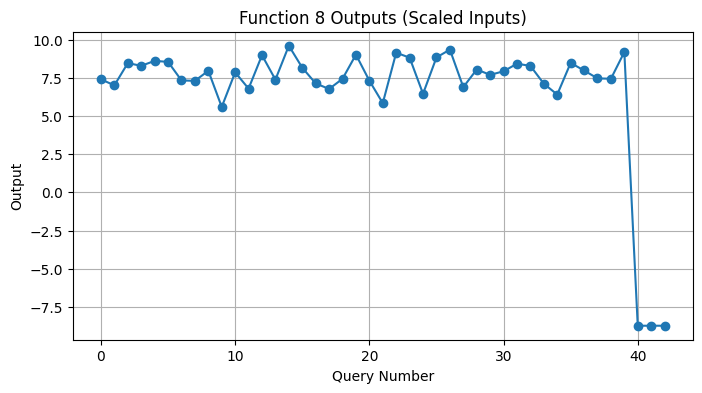

In [39]:
import numpy as np
import matplotlib.pyplot as plt

for fn in range(1, 9):
    X = np.load(f"week_4_scaled/function_{fn}_inputs_scaled.npy")
    y = np.load(f"week_4_scaled/function_{fn}_outputs.npy")

    print(f"\nFunction {fn}")
    print("Mean of scaled inputs:", np.mean(X, axis=0))
    print("Std of scaled inputs:", np.std(X, axis=0))
    print("Best output:", np.max(y))
    print("Mean output:", np.mean(y))

    plt.figure(figsize=(8,4))
    plt.plot(y, marker='o')
    plt.title(f"Function {fn} Outputs (Scaled Inputs)")
    plt.xlabel("Query Number")
    plt.ylabel("Output")
    plt.grid(True)
    plt.show()

In [52]:
!pip install bayesian-optimization

In [58]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

week_4_queries = {}

kappas = {
    1: 5,
    2: 5,
    3: 5,
    4: 5,
    6: 5,
    7: 3,
    8: 2
}

for fn in [1, 2, 3, 4, 6, 7, 8]:

    X = np.load(f"week_4_scaled/function_{fn}_inputs_scaled.npy")
    y = np.load(f"week_4_scaled/function_{fn}_outputs.npy")

    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0),
        alpha=1e-6,
        normalize_y=True
    )
    gp.fit(X, y)

    # create random candidate points in scaled space
    candidates = np.random.uniform(-2, 2, size=(5000, X.shape[1]))

    # predict mean and uncertainty
    mean, std = gp.predict(candidates, return_std=True)

    # UCB acquisition
    ucb = mean + kappas[fn] * std

    # choose best candidate
    best_index = np.argmax(ucb)
    next_query = candidates[best_index]

    week_4_queries[fn] = next_query

    print(f"Function {fn}: {np.round(next_query.astype(float), 6)}")

# Function 5 manual reasoning
week_4_queries[5] = np.mean(
    np.load("week_4_scaled/function_5_inputs_scaled.npy"),
    axis=0
)

print("Function 5:", np.round(week_4_queries[5], 6))

Function 1: [1.590184 0.341853]
Function 2: [-0.928796  0.813571]
Function 3: [-0.319253 -1.928786 -0.287133]
Function 4: [ 0.389445 -0.969641 -1.868811 -1.965015]
Function 6: [ 0.922099 -1.856152  1.58899  -0.782069  0.47298 ]
Function 7: [ 1.36858  -1.915978  0.479741 -1.672134 -0.469396  0.111205]
Function 8: [-1.879867  1.710082 -1.943004 -0.490239 -0.600743  1.875786  0.216106
  0.831798]
Function 5: [-0.  0. -0. -0.]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The opti

In [59]:
# choose best candidate
best_index = np.argmax(ucb)
next_query = candidates[best_index]

week_4_queries[fn] = next_query

print(f"Function {fn}: {np.round(next_query, 6)}")

# Function 5 manual reasoning
week_4_queries[5] = np.mean(
    np.load("week_4_scaled/function_5_inputs_scaled.npy"),
    axis=0
)

print("Function 5:", np.round(week_4_queries[5], 6))

Function 8: [-1.879867  1.710082 -1.943004 -0.490239 -0.600743  1.875786  0.216106
  0.831798]
Function 5: [-0.  0. -0. -0.]
